# 训练效率与系统监测

| 指标名                          | 含义           |
| :--------------------------- | :----------- |
| `timing/forward`             | 前向传播耗时       |
| `timing/backward`            | 反向传播耗时       |
| `timing/generate`            | 模型生成耗时       |
| `timing/update`              | 参数更新耗时       |
| `throughput/tokens_per_sec`  | 每秒处理 token 数 |
| `throughput/samples_per_sec` | 每秒处理样本数      |
| `memory/allocated`           | GPU 显存分配     |
| `memory/reserved`            | GPU 显存预留     |

## 诊断价值：
- timing/generate <font color='red'>占比过高 → 生成瓶颈，可能需要 vLLM 加速</font>
- memory/allocated <font color='red'>持续增长 → 存在显存泄漏</font>

# 八大核心指标详解

## timing/forward —— 前向传播耗时
测量范围：从输入送入模型到 logits/loss 计算完成的耗时。
在 RL 中的特殊性：
- 对于 Actor：forward 包括 prompt 编码 和 response 生成 两个阶段
- 对于 Critic：forward 仅计算 value，通常比 Actor 快

诊断：

| 耗时              | 状态                              |
| :-------------- | :------------------------------ |
| `< 50ms`（单卡 7B） | ✅ 正常                            |
| `> 200ms`       | ⚠️ 检查是否激活了 checkpointing、序列是否过长 |
| 持续增加            | 🚨 可能存在内存碎片或动态图开销累积             |


## timing/backward —— 反向传播耗时
测量范围：loss.backward() 的执行时间。
关键比例：
- 健康状态：backward / forward ≈ 1.5~2.5（因为反向需要计算梯度并回传）
- 如果 backward >> forward × 3：检查是否有不必要的梯度计算（如冻结参数仍在回传）
##  timing/generate —— 模型生成耗时
这是 RL 训练中最特殊的指标。
在标准 SL 训练中不存在这个环节，但在 RLHF/RLVR 中：
- 先用当前策略生成 response（自回归采样）
- 再对生成的序列做 forward/backward
耗时构成：


In [1]:
from IPython.display import Image

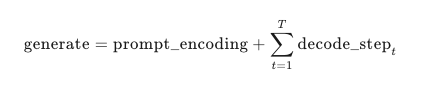

In [2]:
Image(filename='./Image/generate.png')

诊断：

| generate 占比 | 状态                              |
| :---------- | :------------------------------ |
| `< 30%` 总时间 | ✅ 健康                            |
| `30% ~ 50%` | ⚠️ 生成成为瓶颈                       |
| `> 50%`     | 🚨 严重瓶颈，必须用 vLLM/SGLang 等推理引擎加速 |


### 为什么 generate 会占这么高？
- 自回归生成必须逐 token 串行解码，无法并行
- 每次 decode 都要完整过一遍 Transformer（KV Cache 虽能减少计算，但内存带宽仍是瓶颈）
- 生成长度 T  越大，耗时线性增长

## timing/update —— 参数更新耗时
测量范围：optimizer.step() 的执行时间。
通常占比最小（< 5%），但如果：
- 使用了复杂的优化器（如 8-bit Adam、Shampoo）
- 梯度裁剪后触发了大量同步操作
- 参数过多且分布在多卡上

## throughput/tokens_per_sec —— 吞吐量（Token 级）

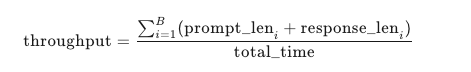

In [3]:
Image(filename='./Image/throughput.png')

这是衡量训练效率的黄金指标。

| 规模             | 参考吞吐量                |
| :------------- | :------------------- |
| 7B 模型，单卡 A100  | ~1000~3000 tokens/s  |
| 70B 模型，8卡 A100 | ~5000~15000 tokens/s |


## throughput/samples_per_sec —— 吞吐量（样本级）

$throughput= \frac{B}{total_time}$

用于评估数据并行效率：
- 如果增加 batch size 但 samples/sec 不增：存在通信瓶颈
- 如果 samples/sec 随 GPU 数线性增长：并行效率良好

## memory/allocated —— GPU 显存分配
PyTorch 显存分配器已分配给张量的显存量。
关键特征：
- 包含当前活跃张量 + 已释放但未被 CUDA 缓存池回收的显存
- 如果持续增长 → 显存泄漏或缓存未释放

##  memory/reserved —— GPU 显存预留
CUDA 显存分配器从 GPU 预留的总显存（包括已分配和缓存中的空闲块）。
与 allocated 的关系：

In [ ]:
reserved = allocated + cached_free

诊断：
- reserved 接近 GPU 总容量 → 即将 OOM
- reserved 持续增长但 allocated 稳定 → PyTorch 缓存池碎片化，可调用 torch.cuda.empty_cache()
- allocated 持续增长 → 存在显存泄漏

# 完整系统监控类

In [ ]:
import torch
import time
from collections import defaultdict
import torch.cuda as cuda

class SystemMonitor:
    """
    verl 风格的训练效率与系统监测器
    覆盖：时间分解、吞吐量、显存、瓶颈诊断
    """
    def __init__(self, device='cuda'):
        self.device = device
        self.timers = {}
        self.history = defaultdict(list)
        self.step_times = {}
    
    def start_timer(self, name):
        """开始计时"""
        cuda.synchronize() if self.device == 'cuda' else None
        self.timers[name] = time.time()
    
    def end_timer(self, name):
        """结束计时并记录"""
        cuda.synchronize() if self.device == 'cuda' else None
        if name in self.timers:
            elapsed = time.time() - self.timers[name]
            self.step_times[name] = elapsed
            self.history[f'timing_{name}'].append(elapsed)
            return elapsed
        return 0.0
    
    def record_memory(self):
        """记录显存状态"""
        if self.device != 'cuda':
            return {}
        
        allocated = cuda.memory_allocated() / 1024**3  # GB
        reserved = cuda.memory_reserved() / 1024**3    # GB
        max_allocated = cuda.max_memory_allocated() / 1024**3
        
        mem_stats = {
            'allocated_gb': allocated,
            'reserved_gb': reserved,
            'max_allocated_gb': max_allocated,
        }
        
        for k, v in mem_stats.items():
            self.history[f'memory_{k}'].append(v)
        
        return mem_stats
    
    def record_throughput(self, num_tokens, num_samples, step_time):
        """记录吞吐量"""
        tok_per_sec = num_tokens / step_time
        samp_per_sec = num_samples / step_time
        
        throughput = {
            'tokens_per_sec': tok_per_sec,
            'samples_per_sec': samp_per_sec,
        }
        
        for k, v in throughput.items():
            self.history[f'throughput_{k}'].append(v)
        
        return throughput
    
    def analyze_bottleneck(self):
        """
        分析当前 step 的时间瓶颈
        """
        if not self.step_times:
            return {}
        
        total = sum(self.step_times.values())
        breakdown = {}
        
        for name, t in self.step_times.items():
            breakdown[f'{name}_pct'] = t / total if total > 0 else 0
        
        # 诊断
        alerts = []
        
        # 1. 生成瓶颈
        gen_pct = breakdown.get('generate_pct', 0)
        if gen_pct > 0.5:
            alerts.append(
                f"🚨 严重生成瓶颈：生成占 {gen_pct*100:.1f}% 总时间！"
                f"建议使用 vLLM/SGLang 加速推理，或降低 max_length"
            )
        elif gen_pct > 0.3:
            alerts.append(
                f"⚠️ 生成占比较高：{gen_pct*100:.1f}%，建议优化生成效率"
            )
        
        # 2. 反向传播异常
        fwd = self.step_times.get('forward', 0)
        bwd = self.step_times.get('backward', 0)
        if fwd > 0 and bwd / fwd > 3:
            alerts.append(
                f"⚠️ 反向传播过慢：backward/forward = {bwd/fwd:.1f}x，"
                f"检查梯度检查点或冻结参数设置"
            )
        
        # 3. 更新耗时异常
        upd = self.step_times.get('update', 0)
        if total > 0 and upd / total > 0.1:
            alerts.append(
                f"⚠️ 参数更新占比过高：{upd/total*100:.1f}%，"
                f"检查优化器类型或分布式同步开销"
            )
        
        return {
            'total_time': total,
            'breakdown': breakdown,
            'alerts': alerts,
        }
    
    def diagnose_memory(self):
        """显存诊断"""
        if not self.history['memory_allocated_gb']:
            return {}
        
        allocated = self.history['memory_allocated_gb'][-1]
        reserved = self.history['memory_reserved_gb'][-1]
        
        # 检测泄漏：allocated 持续增长
        leak_detected = False
        if len(self.history['memory_allocated_gb']) >= 5:
            recent = self.history['memory_allocated_gb'][-5:]
            # 线性拟合斜率
            slope = (recent[-1] - recent[0]) / 5
            if slope > 0.1:  # 每步增长 > 0.1 GB
                leak_detected = True
        
        alerts = []
        if leak_detected:
            alerts.append(
                f"🚨 显存泄漏 detected：allocated 每步增长 ~{slope:.2f} GB，"
                f"检查是否有张量未释放或梯度累积未清空"
            )
        
        # 检测 OOM 风险
        if torch.cuda.is_available():
            total_mem = cuda.get_device_properties(0).total_memory / 1024**3
            if reserved / total_mem > 0.9:
                alerts.append(
                    f"🚨 OOM 风险：显存预留 {reserved:.1f}/{total_mem:.1f} GB "
                    f"({reserved/total_mem*100:.1f}%)，即将溢出！"
                )
        
        return {
            'allocated_gb': allocated,
            'reserved_gb': reserved,
            'leak_detected': leak_detected,
            'alerts': alerts,
        }
    
    def step_summary(self, step, num_tokens, num_samples):
        """生成 step 摘要"""
        print(f"\n{'='*70}")
        print(f"Step {step} 系统效率诊断")
        print(f"{'='*70}")
        
        # 时间分解
        bottleneck = self.analyze_bottleneck()
        if bottleneck:
            print(f"【时间分解】总耗时: {bottleneck['total_time']:.3f}s")
            for name, pct in bottleneck['breakdown'].items():
                bar = '█' * int(pct * 20)
                print(f"  {name:20s}: {pct*100:5.1f}% |{bar:<20s}|")
            
            if bottleneck['alerts']:
                print(f"\n【瓶颈警报】")
                for alert in bottleneck['alerts']:
                    print(f"  {alert}")
        
        # 吞吐量
        if num_tokens > 0 and bottleneck['total_time'] > 0:
            throughput = self.record_throughput(
                num_tokens, num_samples, bottleneck['total_time']
            )
            print(f"\n【吞吐量】{throughput['tokens_per_sec']:.0f} tokens/s, "
                  f"{throughput['samples_per_sec']:.1f} samples/s")
        
        # 显存
        mem_info = self.diagnose_memory()
        if mem_info:
            print(f"\n【显存】allocated: {mem_info['allocated_gb']:.2f} GB, "
                  f"reserved: {mem_info['reserved_gb']:.2f} GB")
            if mem_info['alerts']:
                for alert in mem_info['alerts']:
                    print(f"  {alert}")
        
        print(f"{'='*70}")
        
        # 清空 step 计时
        self.step_times = {}
        
        return bottleneck


# ==================== 使用示例 ====================

print("=" * 70)
print("模拟 verl 风格的 RL 训练循环 + 系统监测")
print("=" * 70)

# 初始化
monitor = SystemMonitor(device='cuda' if torch.cuda.is_available() else 'cpu')

# 模拟模型
model = torch.nn.Transformer(d_model=512, nhead=8, num_encoder_layers=6).cuda() if torch.cuda.is_available() else torch.nn.Transformer(d_model=512, nhead=8, num_encoder_layers=6)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for step in range(10):
    batch_size = 4
    seq_len = 128
    num_tokens = batch_size * seq_len * 2  # prompt + response
    
    # 1. 生成阶段（模拟）
    monitor.start_timer('generate')
    time.sleep(0.05)  # 模拟生成耗时
    monitor.end_timer('generate')
    
    # 2. 前向传播
    monitor.start_timer('forward')
    x = torch.randn(batch_size, seq_len, 512).cuda() if torch.cuda.is_available() else torch.randn(batch_size, seq_len, 512)
    if torch.cuda.is_available():
        x = x.cuda()
    out = model(x, x)
    monitor.end_timer('forward')
    
    # 3. 反向传播
    monitor.start_timer('backward')
    loss = out.mean()
    loss.backward()
    monitor.end_timer('backward')
    
    # 4. 参数更新
    monitor.start_timer('update')
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    optimizer.zero_grad()
    monitor.end_timer('update')
    
    # 5. 记录显存
    monitor.record_memory()
    
    # 6. 诊断（每 2 步）
    if step % 2 == 0:
        monitor.step_summary(step, num_tokens, batch_size)

# 模拟显存泄漏场景
print("\n" + "=" * 70)
print("模拟显存泄漏检测")
print("=" * 70)

monitor2 = SystemMonitor()
# 模拟 allocated 持续增长
for _ in range(10):
    monitor2.history['memory_allocated_gb'].append(10 + _ * 0.5)  # 每步 +0.5GB

leak_info = monitor2.diagnose_memory()
if leak_info['alerts']:
    for alert in leak_info['alerts']:
        print(alert)

# RL 训练中的特殊优化策略
基于系统监测数据，verl 等框架会动态调整：

| 瓶颈                  | 优化策略                                                        |
| :------------------ | :---------------------------------------------------------- |
| `generate` 占比 > 50% | 使用 **vLLM/SGLang** 替代原生生成；启用 **投机解码**（Speculative Decoding） |
| `forward` 占比高       | 启用 **FlashAttention**；使用 **Gradient Checkpointing** 换时间     |
| `backward` 异常慢      | 检查 **ZeRO Stage** 配置；减少激活值保留                                |
| 显存泄漏                | 调用 `torch.cuda.empty_cache()`；检查 `no_grad()` 上下文            |
| OOM 风险              | 降低 batch size；启用 **序列并行**；使用 **Offload**                    |

# 时间分解的理想比例
- 如果 generate 超过 40%，说明推理引擎是瓶颈，必须外置加速。

In [ ]:
健康 RL 训练的时间分配：
┌─────────────────────────────────────────────┐
│  generate  ████████████░░░░  25%            │
│  forward   ████████░░░░░░░░  20%            │
│  backward  ██████████████░░  30%            │
│  update    ██░░░░░░░░░░░░░░   5%            │
│  overhead  ████░░░░░░░░░░░░  20% (通信等)    │
└─────────────────────────────────────────────┘

## 一句话总结
- 系统监测是 RL 训练的"性能仪表盘"：时间分解告诉你瓶颈在哪一步（生成/前向/反向），吞吐量告诉你硬件利用率，显存曲线告诉你离 OOM 还有多远。在 LLM+RL 中，生成阶段往往是最大瓶颈——监测它，优化它，训练效率才能翻倍。